In [43]:
import os, numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

ROOT = os.environ.get("LPP_DATA", os.path.join("..", "data"))
FIGDIR = os.path.join("..", "figures")
os.makedirs(FIGDIR, exist_ok=True)

mpl.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "font.family": "serif", "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.linewidth": 0.8, "axes.titlesize": 15, "axes.labelsize": 15,
    "xtick.labelsize": 15, "ytick.labelsize": 15, "legend.fontsize": 15,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})
POINT = "#1f77b4"

def load(name): return pd.read_csv(os.path.join(ROOT, name))

final = load("final_data.csv").rename(columns={"Participation Ratio":"PR","Effective Rank":"ER","Entropy":"EntropyFloor"})
tqa   = load("ext_truthfulqa.csv")
symb  = load("ext_symbolic.csv")
norm  = load("normalized_metrics.csv")
nb2   = load("nb2_merged.csv")
D = final.merge(tqa, on="Model").merge(symb, on="Model").merge(norm, on="Model")

def scatter(ax, df, x, y, xlabel, ylabel, title):
    for _, r in df.iterrows():
        ax.scatter(r[x], r[y], s=200, color=POINT, edgecolor="k", linewidth=0.4, zorder=3)
        ax.annotate(r["Model"], (r[x], r[y]), fontsize=12, xytext=(-25,9),
                    textcoords="offset points", clip_on=True)
    xs = df[x].values.astype(float); ys = df[y].values.astype(float)
    b, a = np.polyfit(xs, ys, 1)
    xg = np.linspace(xs.min(), xs.max(), 50)
    ax.plot(xg, a + b*xg, "--", color="0.4", lw=1.0, zorder=1)
    rho, p = spearmanr(xs, ys)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(f"{title}\n"+r"$\rho$"+f"={rho:.2f}, p={p:.3f}", fontsize=15)
    for s in ("top","right"): ax.spines[s].set_visible(False)
    #ax.grid(True, color="#ececec", lw=0.6)
    ax.margins(x=0.16, y=0.10)

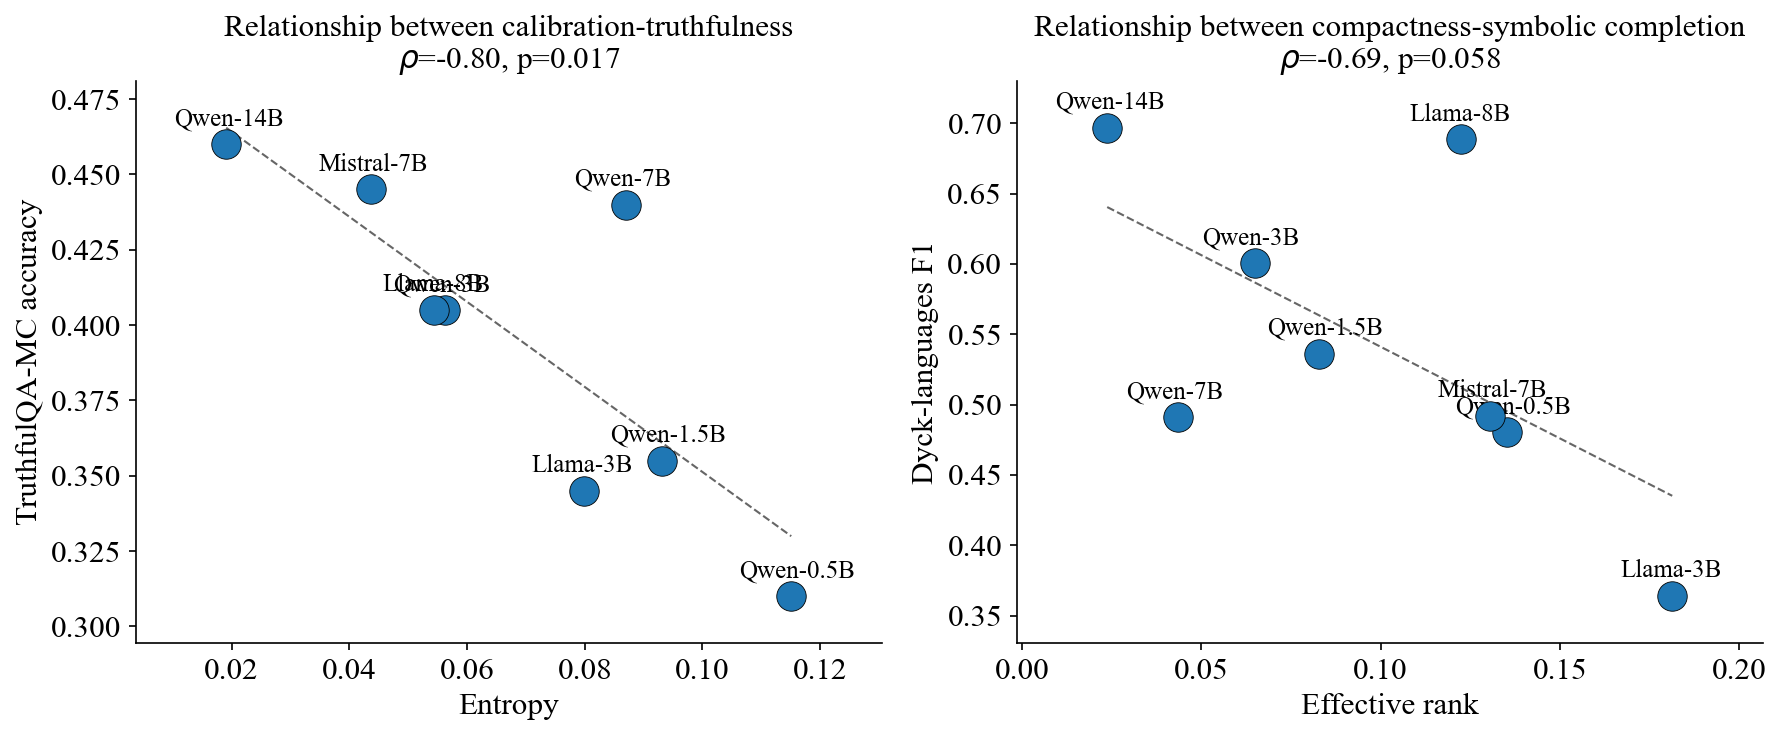

In [45]:
# ---------------- FIGURE 1a: external benchmarks (TruthfulQA + Dyck) ----------------
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
scatter(ax[0], D, "EntropyFloor", "TQA_acc",
        "Entropy", "TruthfulQA-MC accuracy",
        "Relationship between calibration-truthfulness")
scatter(ax[1], D, "ER", "dyck_f1",
        "Effective rank", "Dyck-languages F1",
        "Relationship between compactness-symbolic completion")
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR,"external_truthful_dyck.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(ROOT,"fig_external_truthful_dyck.svg"), bbox_inches="tight", dpi=300)
plt.show()
plt.close(fig)

In [46]:
nb2['claude_reliability'] /= 2

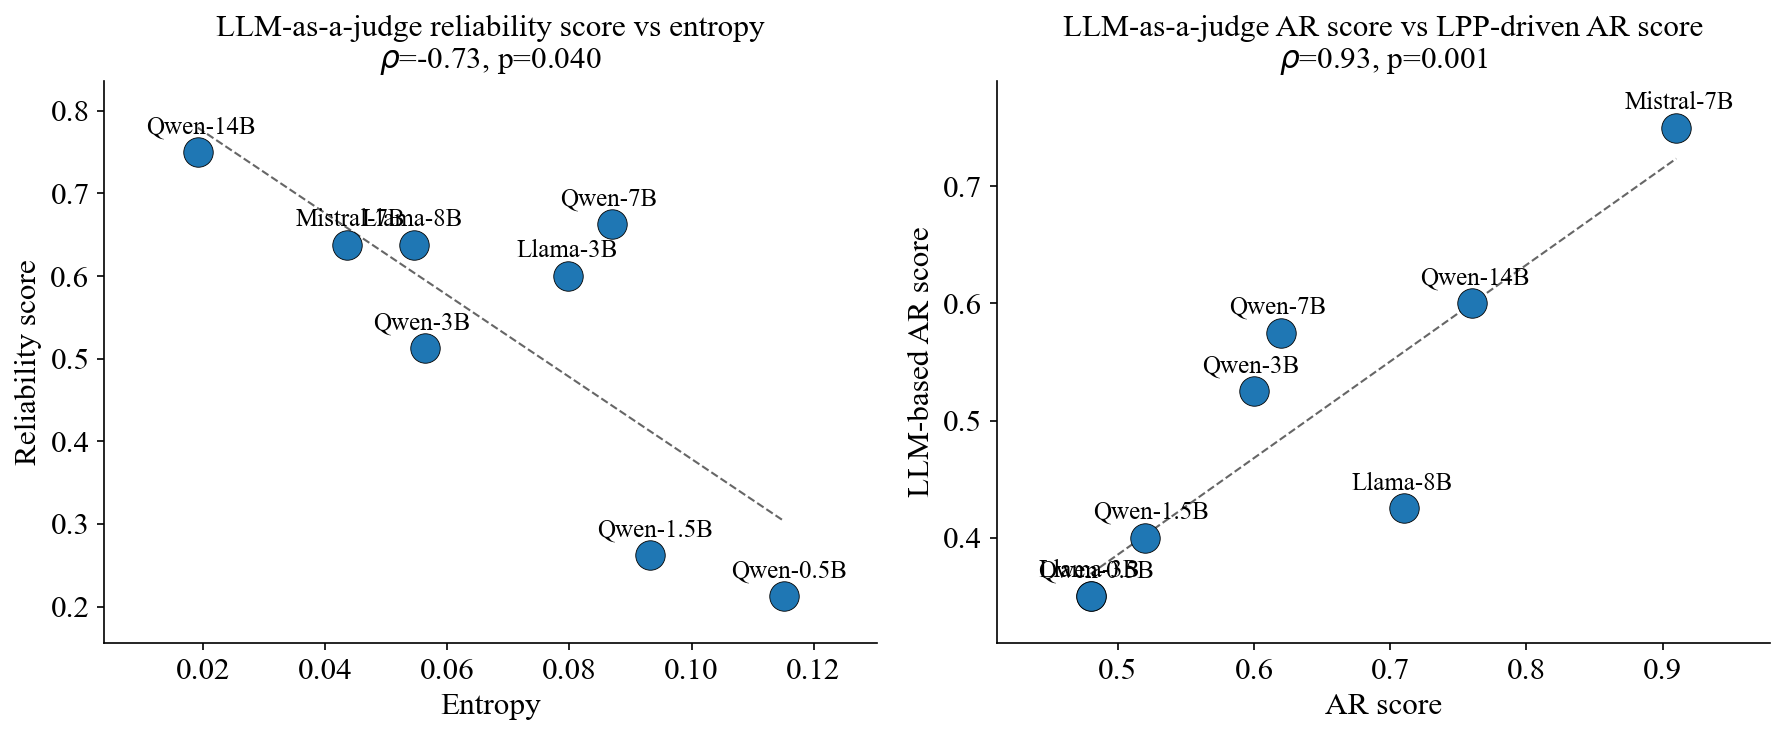

In [47]:
# ---------------- FIGURE 1b: independent-judge (Claude) results ----------------
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
scatter(ax[0], nb2, "EntropyFloor", "claude_reliability",
        "Entropy", "Reliability score",
        "LLM-as-a-judge reliability score vs entropy")
scatter(ax[1], nb2, "AR", "claude_AR_acc",
        "AR score", "LLM-based AR score",
        "LLM-as-a-judge AR score vs LPP-driven AR score")
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR,"external_claude.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(ROOT,"fig_external_claude.svg"), bbox_inches="tight", dpi=300)
plt.show()
plt.close(fig)

In [44]:
# ---------------- FIGURE 2: outlier robustness (2 panels, robust only) ----------------
fig, ax = plt.subplots(1, 2, figsize=(8.6, 3.9))
# A: variance share of top-1 / top-5 dimensions
order = norm.sort_values("top5_var_share")
x = np.arange(len(order))
ax[0].bar(x-0.2, order["top1_var_share"], 0.4, label="top-1 dim", color="#4a78b5", edgecolor="k", lw=0.4)
ax[0].bar(x+0.2, order["top5_var_share"], 0.4, label="top-5 dims", color="#b5c9e5", edgecolor="k", lw=0.4)
ax[0].set_xticks(x); ax[0].set_xticklabels(order["Model"], rotation=45, ha="right")
ax[0].set_ylabel("Fraction of total variance")
ax[0].set_title("Outlier concentration for participation ratio"); ax[0].legend(frameon=False)
# B: PR under raw vs robust (winsorized) only
o2 = norm.sort_values("PR_raw"); x2 = np.arange(len(o2))
ax[1].plot(x2, o2["PR_raw"], "o-", label="PR (current)", color="#1f77b4")
ax[1].plot(x2, o2["PR_robust"], "^--", label="Winsorized PR", color="#2ca02c")
ax[1].set_xticks(x2); ax[1].set_xticklabels(o2["Model"], rotation=45, ha="right")
ax[1].set_ylabel("Participation ratio")
ax[1].set_title("PR with winsorization"); ax[1].legend(frameon=False)
for a in ax:
    for s in ("top","right"): a.spines[s].set_visible(False)
    a.grid(True, axis="y", color="#ececec", lw=0.6)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR,"outlier_robustness.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(ROOT,"fig_outlier_robustness.png"), bbox_inches="tight", dpi=150)
plt.close(fig)

print("Saved figures to", FIGDIR)
print("\nKEY NUMBERS")
print("Entropy~TQA:", round(spearmanr(D.EntropyFloor, D.TQA_acc)[0],3))
print("ER~Dyck:", round(spearmanr(D.ER, D.dyck_f1)[0],3), "| PR_robust~Dyck:", round(spearmanr(D.PR_robust, D.dyck_f1)[0],3))
print("Entropy~Claude reliability:", round(spearmanr(nb2.EntropyFloor, nb2.claude_reliability)[0],3))
print("AR~Claude AR:", round(spearmanr(nb2.AR, nb2.claude_AR_acc)[0],3))
print("raw vs robust rank corr PR:", round(pearsonr(norm.PR_raw, norm.PR_robust)[0],3),
      "ER:", round(pearsonr(norm.ER_raw, norm.ER_robust)[0],3))

Saved figures to ./paper/figures

KEY NUMBERS
Entropy~TQA: -0.802
ER~Dyck: -0.69 | PR_robust~Dyck: -0.81
Entropy~Claude reliability: -0.731
AR~Claude AR: 0.928
raw vs robust rank corr PR: 1.0 ER: 1.0
